**1. Data setup**

**1a. Load in sEMG data from UCI ML Repository**

In [1]:
import pandas as pd
import glob
import os

def preprocess_emg_folder(folder_path):
    folder_list = glob.glob(os.path.join(folder_path, "*/"))
    full_features = []
    full_labels = []

    for folder in folder_list:
        file_list = glob.glob(os.path.join(folder, "*.txt"))

        for file in file_list:
            # Load data: Time (0), Channels (1-8), Class (9)
            df = pd.read_csv(file, sep=r"\s+")

            # Features: columns 1-8 (8 EMG channels)
            features = df.iloc[:, 1:9].values

            # Labels: column 9 (gesture class)
            labels = df.iloc[:, 9].values

            # Remove unmarked data (label == 0)
            valid = (labels != 0)
            features = features[valid]
            labels = labels[valid]

            # Shift labels 1-7 -> 0-6
            labels = labels - 1

            full_features.extend(features)
            full_labels.extend(labels)

    return full_features, full_labels

# Load raw data
X_raw, y_raw = preprocess_emg_folder("./Data")

print("Raw feature shape:", len(X_raw), "samples,", len(X_raw[0]), "channels")
print("Raw label shape:", len(y_raw))

Raw feature shape: 1512751 samples, 8 channels
Raw label shape: 1512751


**1b. Normalize + Clean data**

In [2]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Convert to numpy arrays
X_raw = np.array(X_raw)
y_raw = np.array(y_raw)

# Normalize features: mean=0, std=1
scaler = StandardScaler()
X_raw = scaler.fit_transform(X_raw)

# Remove any NaNs just in case
temp_df = pd.DataFrame(X_raw)
temp_df["label"] = y_raw
clean_df = temp_df.dropna()

X_raw = clean_df.drop(columns=["label"]).values
y_raw = clean_df["label"].values

print("Cleaned X_raw shape:", X_raw.shape)
print("Cleaned y_raw shape:", y_raw.shape)

Cleaned X_raw shape: (1512750, 8)
Cleaned y_raw shape: (1512750,)


**1c. Quick Check to view data**

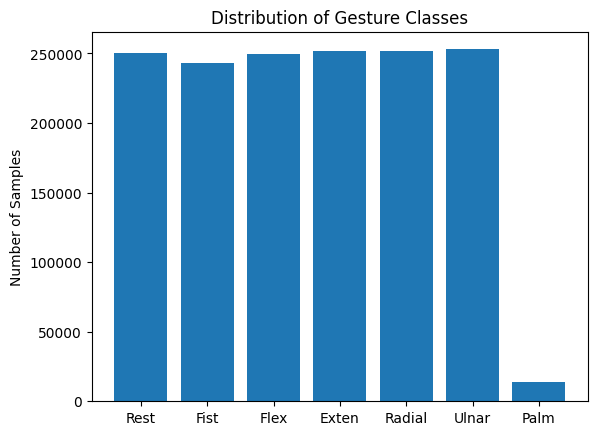

In [3]:
import matplotlib.pyplot as plt

gesture_names = ['Rest', 'Fist', 'Flex', 'Exten', 'Radial', 'Ulnar', 'Palm']

plt.hist(y_raw, bins=range(8), align='left', rwidth=0.8)
plt.xticks(range(7), gesture_names)
plt.title("Distribution of Gesture Classes")
plt.ylabel("Number of Samples")
plt.show()

**1d. Time-Window Data**

In [4]:
import numpy as np

def isPure_window(y_win):
    # "pure" means all labels inside the window are the same gesture
    return np.all(y_win == y_win[0])

def create_windows_pure(X, y, window_size=64, stride=1):
    X_win = []
    y_win = []

    for i in range(0, len(y) - window_size + 1, stride):
        X_temp = X[i : i + window_size]      # shape (64, 8)
        y_temp = y[i : i + window_size]      # shape (64,)

        if not isPure_window(y_temp):
            continue

        # transpose to (8, 64) like your notebook
        X_win.append(X_temp.T)
        y_win.append(y[i])

    return np.array(X_win), np.array(y_win)

X_win, y_win = create_windows_pure(X_raw, y_raw, window_size=64, stride=1)

print("Windowed X_win shape:", X_win.shape)  # (N, 8, 64)
print("Windowed y_win shape:", y_win.shape)  # (N,)

Windowed X_win shape: (1457814, 8, 64)
Windowed y_win shape: (1457814,)


**1e. Train Test Split**

In [5]:
from sklearn.model_selection import train_test_split

RAND_NUM = 25

# SVM expects 2D: (samples, features)
# Flatten each window (8, 64) -> (512,)
X_flat = X_win.reshape(X_win.shape[0], -1)

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_win,
    test_size=0.2,
    random_state=RAND_NUM,
    stratify=y_win
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1166251, 512)
Test shape: (291563, 512)


**2. Setup Model Training**

**2a. Set up layers for SVM**

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),  # IMPORTANT for SVM
    ("clf", LinearSVC(
        C=1.0,                    # strength of the boundary
        class_weight="balanced",  # helps if classes are imbalanced
        random_state=RAND_NUM,
        max_iter=10000
    ))
])

svm_model.fit(X_train, y_train)
print("SVM training complete!")

SVM training complete!


**3 Evaluate Model**


**3a. Accuracy & report**

In [7]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=gesture_names))

Accuracy: 0.23285533486759294

Classification Report:
              precision    recall  f1-score   support

        Rest       0.32      0.27      0.29     48197
        Fist       0.23      0.29      0.26     46824
        Flex       0.21      0.16      0.18     48084
       Exten       0.26      0.50      0.34     48500
      Radial       0.17      0.05      0.07     48532
       Ulnar       0.21      0.14      0.17     48788
        Palm       0.02      0.14      0.04      2638

    accuracy                           0.23    291563
   macro avg       0.20      0.22      0.19    291563
weighted avg       0.23      0.23      0.22    291563



**3b. Confusion Matrix**

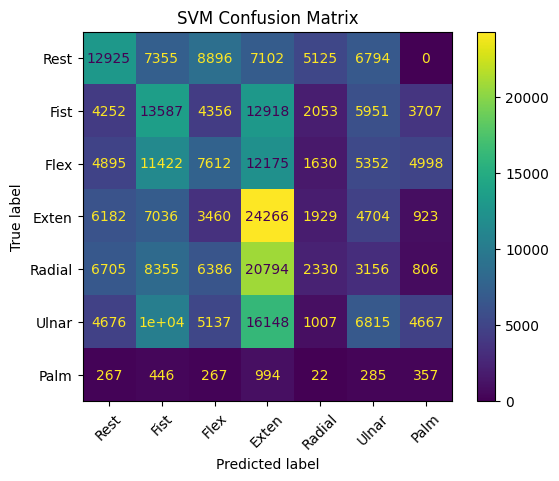

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gesture_names)

disp.plot(xticks_rotation=45)
plt.title("SVM Confusion Matrix")
plt.show()

**3c. PCA visualization**

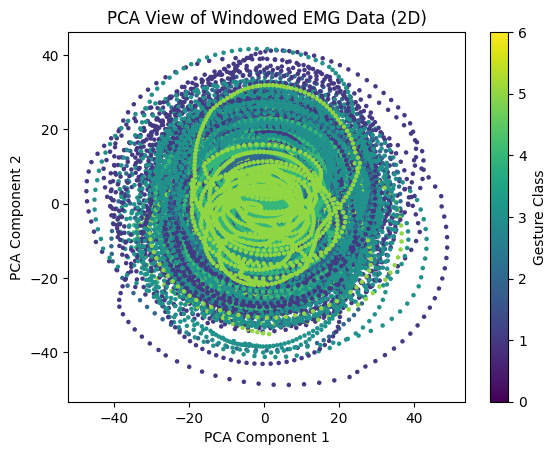

Explained variance by PCA components: [0.0582028  0.05578871]


In [9]:
from sklearn.decomposition import PCA

# Reduce high dimensional windows (512 dims) -> 2 dims for plotting
pca = PCA(n_components=2, random_state=RAND_NUM)
X_2d = pca.fit_transform(X_flat)

plt.figure()
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_win, s=5)
plt.title("PCA View of Windowed EMG Data (2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, ticks=range(7), label="Gesture Class")
plt.show()

print("Explained variance by PCA components:", pca.explained_variance_ratio_)

**4. Save Model**

In [ ]:
import pickle
import os

os.makedirs("./model", exist_ok=True)
MODELFILE = "./model/sEMG_LinearSVM.pkl"

with open(MODELFILE, "wb") as f:
    pickle.dump(svm_model, f)

print("Saved model to:", MODELFILE)

Saved model to: ./model/sEMG_LinearSVM.pkl
